# 进阶实践项目 03 参考答案：原图级形态表征、代表图块与染色稳定性

体验数据没有患者级 WHO 分级或结局标签，因此本答案不构造临床分类标签。它展示无标签条件下仍然可以严谨完成的分析：图块特征、bag 聚合、原图嵌入、代表图块和染色扰动稳定性。拥有真实标签时，可以在同一 bag 表征上增加原图级交叉验证。


> **实践定位**
>
> 这不是短时间代码竞赛，也不是以最高分数决定完成度的作业。可以只完成数据核对、基线、一个消融实验或一段严谨的失败分析。问题定义、文献依据、方法选择、验证设计、错误解释和下一步实验，重要性高于单一性能数值。
>
> 最终提交由两部分组成：当前 Notebook，以及一份设计报告。设计报告不是代码说明书，而是研究方案说明。参考答案只展示一种能够运行的方案，不代表唯一正确答案，也不意味着其中的模型一定最适合你的目标。

**参考答案不是唯一正确答案。** 其他方案只要问题定义、数据处理、验证和解释合理，同样可以成立。

## 对应题目 1：环境与数据发现

搜索宽高至少 1000 像素的完整图像，排除网页示意图和缩略图。若未挂载数据，生成明确标记的组织纹理演示图，只用于检查代码。


In [1]:
from pathlib import Path
import json
import numpy as np,matplotlib.pyplot as plt
from PIL import Image,ImageEnhance
from skimage.color import rgb2hed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
SEED=42;OUT=Path('/kaggle/working') if Path('/kaggle').exists() else Path('outputs_adv03');OUT.mkdir(exist_ok=True)

def find_originals():
 ims=[];paths=[]
 for root in [Path('/kaggle/input')]:
  if not root.exists():continue
  for ext in ('*.png','*.jpg','*.jpeg','*.tif','*.tiff'):
   for p in root.glob('**/'+ext):
    try:
     im=Image.open(p).convert('RGB')
     if im.width>=1000 and im.height>=1000:ims.append(np.array(im));paths.append(str(p))
    except Exception:pass
 return ims[:12],paths[:12]
def synth():
 out=[]
 for i in range(12):
  r=np.random.default_rng(i);a=np.full((768,1024,3),[235,185,205],np.float32);n=2200+i*150
  yy=r.integers(0,a.shape[0],n);xx=r.integers(0,a.shape[1],n);rad=r.integers(2,6,n)
  for y,x,z in zip(yy,xx,rad):
   a[max(0,y-z):min(a.shape[0],y+z),max(0,x-z):min(a.shape[1],x+z)]=[90+r.integers(30),55,125+r.integers(40)]
  out.append(np.clip(a+r.normal(0,5,a.shape),0,255).astype(np.uint8))
 return out
originals,paths=find_originals()
if len(originals)<6:
 originals=synth();paths=[f'demo_{i}' for i in range(len(originals))];mode='demo'
else:
 mode='real'
print(mode,len(originals))


demo 12


## 对应题目 2：图块特征与权重

每个图块提取 RGB 均值/标准差、HED 苏木精通道均值/离散程度和高分位数。该特征只是一种可解释基线。核相关权重强调苏木精信号较强区域，但不能被解释为高等级或高风险区域。


In [2]:
def tile_features(im,patch=192):
 feats=[];scores=[];tiles=[];coords=[]
 for y in range(0,im.shape[0]-patch+1,patch):
  for x in range(0,im.shape[1]-patch+1,patch):
   t=np.array(Image.fromarray(im[y:y+patch,x:x+patch]).resize((96,96)))
   if t.mean()>245:continue
   h=np.clip(rgb2hed(t)[...,0],0,None);score=float(h.mean())
   f=[t[...,k].mean()/255 for k in range(3)]+[t[...,k].std()/255 for k in range(3)]+[score,float(h.std()),float(np.quantile(h,.9))]
   feats.append(f);scores.append(score);tiles.append(t);coords.append((x,y))
 return np.array(feats),np.array(scores),tiles,coords

def aggregate_image(im):
 f,s,tiles,coords=tile_features(im);w=np.exp((s-s.mean())/(s.std()+1e-6));w/=w.sum()
 emb=np.r_[f.mean(0),f.max(0),(f*w[:,None]).sum(0)]
 return emb,f,s,tiles,coords,w
packs=[aggregate_image(im) for im in originals];X=np.stack([p[0] for p in packs]);print('bag embedding',X.shape)


bag embedding (12, 27)


## 对应题目 3：原图嵌入与聚类

PCA 只用于低维展示；KMeans 的两个簇是数据驱动的形态分组，不能命名为临床亚型。轮廓系数只描述当前特征空间中的分离程度，样本量 12 时不稳定。


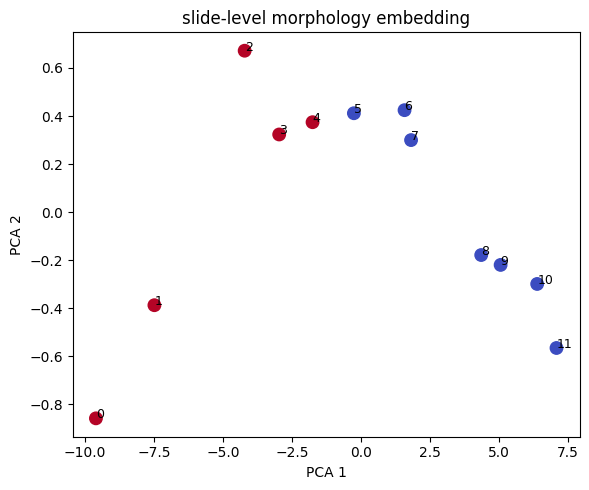

silhouette 0.5321358563296049


In [3]:
Xs=StandardScaler().fit_transform(X)
n_components=min(2,len(X),Xs.shape[1])
Z0=PCA(n_components=n_components,random_state=SEED).fit_transform(Xs)
Z=np.column_stack([Z0,np.zeros(len(Z0))]) if n_components==1 else Z0
labels=KMeans(min(2,len(X)),random_state=SEED,n_init=20).fit_predict(Xs)
sil=float(silhouette_score(Xs,labels)) if len(set(labels))>1 else float('nan')
plt.figure(figsize=(6,5));plt.scatter(Z[:,0],Z[:,1],c=labels,cmap='coolwarm',s=80)
for i,(x,y) in enumerate(Z):plt.text(x,y,str(i),fontsize=9)
plt.xlabel('PCA 1');plt.ylabel('PCA 2');plt.title('slide-level morphology embedding');plt.tight_layout();plt.savefig(OUT/'adv03_embedding.png',dpi=150);plt.show()
print('silhouette',sil)


## 对应题目 4：代表图块

每张原图选择核相关权重最高的图块作为“模型聚合中最被强调的图块”，并同时显示接近平均特征的代表图块。二者都需要人工检查组织、空白、折叠和染色伪影。


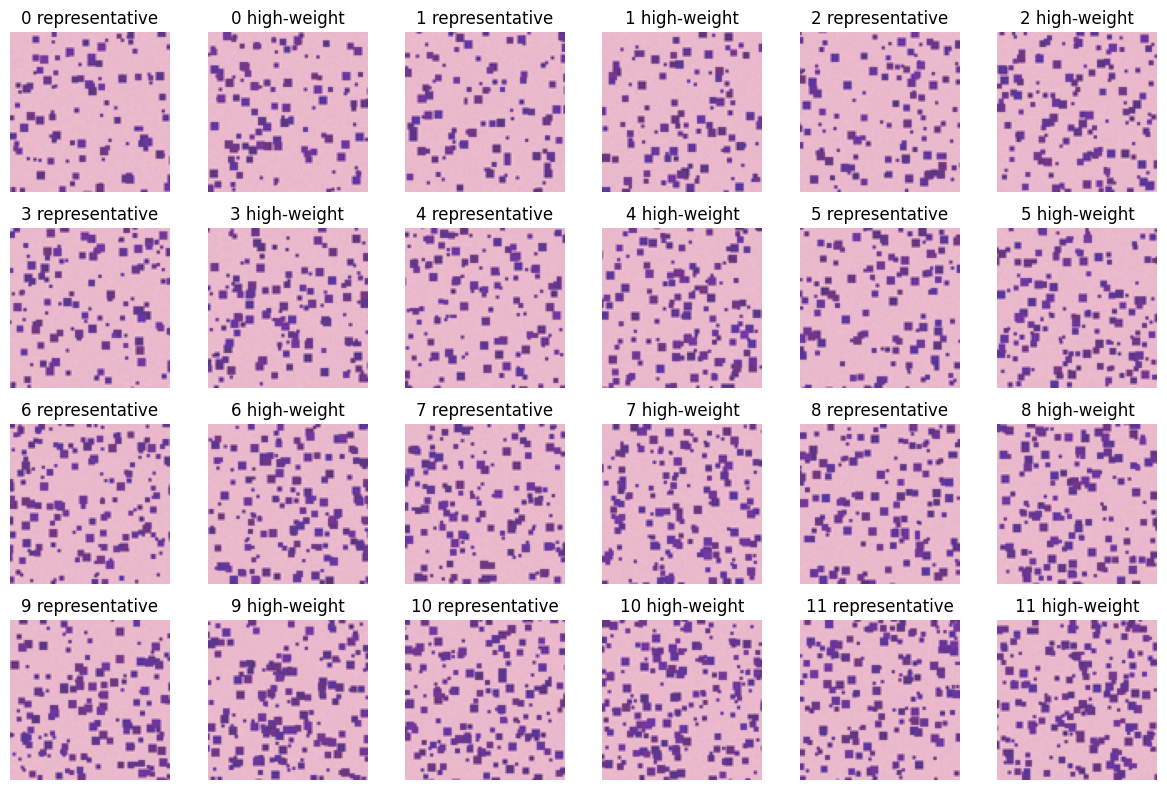

In [4]:
fig,ax=plt.subplots(4,6,figsize=(12,8))
for i in range(min(12,len(packs))):
 emb,f,s,tiles,coords,w=packs[i];hi=int(np.argmax(w));mean=int(np.argmin(np.linalg.norm(f-f.mean(0),axis=1)))
 r=i//3;c=(i%3)*2
 ax[r,c].imshow(tiles[mean]);ax[r,c].set_title(f'{i} representative');ax[r,c].axis('off')
 ax[r,c+1].imshow(tiles[hi]);ax[r,c+1].set_title(f'{i} high-weight');ax[r,c+1].axis('off')
plt.tight_layout();plt.savefig(OUT/'adv03_representative_patches.png',dpi=150);plt.show()


## 对应题目 5：染色扰动稳定性

使用颜色增强器产生轻度饱和度和对比度变化，不改变空间结构。重新计算 bag embedding 后比较余弦相似度。高相似度说明当前手工表征对这一类扰动较稳定；它不能覆盖扫描仪、实验批次和严重染色漂移。


In [5]:
def perturb(im):
 x=Image.fromarray(im);x=ImageEnhance.Color(x).enhance(1.18);x=ImageEnhance.Contrast(x).enhance(.90);return np.array(x)
Xp=np.stack([aggregate_image(perturb(im))[0] for im in originals])
cos=np.sum(X*Xp,1)/(np.linalg.norm(X,axis=1)*np.linalg.norm(Xp,axis=1)+1e-8)
metrics={'mode':mode,'n_images':len(originals),'silhouette_2clusters':sil,'mean_embedding_cosine_after_stain_shift':float(np.mean(cos)),'min_embedding_cosine_after_stain_shift':float(np.min(cos)),'clinical_labels_used':False}
print(metrics);json.dump(metrics,open(OUT/'adv03_result.json','w'),ensure_ascii=False,indent=2)


{'mode': 'demo', 'n_images': 12, 'silhouette_2clusters': 0.5321358563296049, 'mean_embedding_cosine_after_stain_shift': 0.9996660017976979, 'min_embedding_cosine_after_stain_shift': 0.9996083427854892, 'clinical_labels_used': False}


## 如何对应题目阅读本答案

- 数据与完整原图检查：第 1 部分；
- 图块特征和 bag 聚合：第 2 部分；
- 原图级无监督分析：第 3 部分；
- 代表/高权重图块：第 4 部分；
- 染色稳定性：第 5 部分。

若获得真实患者或玻片标签，可在固定的 bag embedding 上使用按患者分组的交叉验证，或训练注意力 MIL。参考答案刻意不使用由同一特征构造的伪标签，以避免循环结论。

完整的示范研究说明见同目录 `项目03_参考设计报告.md`。其中包括研究问题、数据独立性、文献依据、方法选择、评价、结果解释、局限、下一步实验和本包运行记录。它仍然只是一种参考方案。